In [254]:
# Basic libraries 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pykalman import KalmanFilter
from itertools import combinations
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import coint
import statsmodels.api as sm
import pickle
import os
import sys

PROJECT_ROOT = os.path.abspath("..")
sys.path.insert(0, PROJECT_ROOT)

In [255]:
# Scripts 
from src.cointegration import *
from src.kalman import *
from src.pairs import *
from src.trading_signal import *
from src.backtest import *
from src.plots import *
from src.utils import *

In [256]:
# Load in data from previous notebook
df1_is = pd.read_csv("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/df1_is",
                     index_col=0, parse_dates=True)
df1_oos = pd.read_csv("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/df1_oos",
                      index_col=0, parse_dates=True)

df2_is = pd.read_csv("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/df2_is",
                     index_col=0, parse_dates=True)
df2_oos = pd.read_csv("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/df2_oos",
                      index_col=0, parse_dates=True)

# Create pairs strategy (Static vs. Dynamic (Kalman))
- Start with the static hedge ratio (using OLS) (pairs.py)
- Develop the Kalman Filter script here (kalman.py)
- Create the dynamic model here and standardise to form the trading signal (pairs.py)

Static Hedge Ratio (**Benchmark**):
$$
y_t = \alpha + \beta x_t + \epsilon_t
$$
$$
\text{spread}_t = y_t - \alpha - \beta x_t
$$

Dynamic Hedge Ratio (**Kalman Filter Implementation**):
$$
y_t = \alpha_t + \beta_t x_t + \epsilon_t
$$
$$
\text{spread}_t = y_t - \alpha_t - \beta_t x_t
$$

### Difference between Static Hedge Ratio and Dynamic Hedge Ratio

| Feature | Static Hedge Ratio (OLS) | Dynamic Hedge Ratio (Kalman Filter) |
|--------|--------------------------|--------------------------------------|
| Model | $y_t = \alpha + \beta x_t + \epsilon_t$ | $y_t = \alpha_t + \beta_t x_t + \epsilon_t $ |
| Hedge Ratio | Constant $\beta$ | Time-varying $\beta_t$|
| Estimation Method | Ordinary Least Squares (OLS) | Kalman Filter (state-space model) |
| Parameter Updates | Estimated once using full sample | Updated recursively at each time step |
| Adaptability | None (fixed relationship) | High (adapts to new data) |
| Assumption | Stable long-run relationship | Relationship evolves over time |
| Sensitivity to Regime Changes | Poor | Better (can adjust to changing dynamics) |
| Noise Handling | Does not explicitly model uncertainty | Explicitly models observation and state noise |
| Spread Construction | $y_t - \alpha - \beta x_t$ | $y_t - \alpha_t - \beta_t x_t$ |
| Computational Complexity | Low | Moderate |
| Risk of Overfitting | Lower | Higher if poorly tuned |
| Realism in Financial Markets | Lower | Higher |


In [257]:
pairs_is = [
    {"y": "700 HK Equity", "x": "1347 HK Equity", "df": df1_is},
    {"y": "1347 HK Equity", "x": "268 HK Equity", "df": df1_is},
    {"y": "1088 HK Equity", "x": "3993 HK Equity", "df": df2_is},
    {"y": "1088 HK Equity", "x": "1171 HK Equity", "df": df2_is},
    {"y": "3993 HK Equity", "x": "2689 HK Equity", "df": df2_is},
    {"y": "1898 HK Equity", "x": "2386 HK Equity", "df": df2_is},
]

## Static Hedge Ratio

In [258]:
static_summaries_is = []
static_spreads_is = {}
static_models_is = {}

for pair in pairs_is:
    y_series = pair["df"][pair["y"]]
    x_series = pair["df"][pair["x"]]
    pair_name = f"{pair['y']} vs {pair['x']}"

    summary_df, spread, model = estimate_hedge_ratio_df(
        y_series,
        x_series,
        pair_name=pair_name
    )

    static_summaries_is.append(summary_df)
    static_spreads_is[pair_name] = spread
    static_models_is[pair_name] = model

static_results_df_is = pd.concat(static_summaries_is, ignore_index=True)

In [259]:
static_results_df_is

,pair,alpha,beta,r_squared,n_obs
0,700 HK Equity vs 1347 HK Equity,3.348536,0.851246,0.815995,1478
1,1347 HK Equity vs 268 HK Equity,1.354715,0.679160,0.860079,1478
2,1088 HK Equity vs 3993 HK Equity,1.638806,0.474138,0.767573,1478
3,1088 HK Equity vs 1171 HK Equity,1.862171,0.646130,0.862244,1478
4,3993 HK Equity vs 2689 HK Equity,-1.462759,1.213595,0.851667,1478
5,1898 HK Equity vs 2386 HK Equity,0.049860,0.607067,0.483624,1478


## Dynamic Hedge Ratio

In [260]:
dynamic_summaries_is = []
dynamic_spreads_is = {}
dynamic_details_is = {}

obs_cov_values = [0.5, 1.0, 5.0]

for pair in pairs_is:
    y_series = pair["df"][pair["y"]]
    x_series = pair["df"][pair["x"]]
    pair_name = f"{pair['y']} vs {pair['x']}"

    for r in obs_cov_values:
        summary_df, spread, data = estimate_dynamic_hedge_ratio_df(
            y_series,
            x_series,
            pair_name=pair_name,
            obs_cov=r
        )

        summary_df["obs_cov"] = r
        summary_df["pair"] = pair_name

        key = (pair_name, r)

        dynamic_summaries_is.append(summary_df)
        dynamic_spreads_is[key] = spread
        dynamic_details_is[key] = data

dynamic_results_df_is = pd.concat(dynamic_summaries_is, ignore_index=True)

In [261]:
dynamic_results_df_is.sort_values(
    by=["obs_cov", "pair"]
    ).reset_index(drop=True)

,pair,obs_cov (R),alpha_t_last,beta_t_last,beta_t_mean,beta_t_std,obs_cov
0,1088 HK Equity vs 1171 HK Equity,0.5,1.908583,0.419344,0.511655,0.127085,0.5
1,1088 HK Equity vs 3993 HK Equity,0.5,1.798029,0.281631,0.394832,0.104213,0.5
2,1347 HK Equity vs 268 HK Equity,0.5,1.472719,0.669926,0.538561,0.129216,0.5
3,1898 HK Equity vs 2386 HK Equity,0.5,0.046798,0.515942,0.487637,0.088619,0.5
4,3993 HK Equity vs 2689 HK Equity,0.5,-0.646552,0.813745,0.650795,0.223637,0.5
5,700 HK Equity vs 1347 HK Equity,0.5,4.180828,0.558433,0.981829,0.301003,0.5
6,1088 HK Equity vs 1171 HK Equity,1.0,1.879847,0.467494,0.540162,0.122936,1.0
7,1088 HK Equity vs 3993 HK Equity,1.0,1.749563,0.325712,0.437102,0.102644,1.0
8,1347 HK Equity vs 268 HK Equity,1.0,1.448037,0.667840,0.566071,0.124517,1.0
9,1898 HK Equity vs 2386 HK Equity,1.0,0.050433,0.501387,0.471201,0.084448,1.0


### Plotting hedge ratios 
- First, we will start by plotting each of the pairs (with the different observation covariances) - sensitivity analysis
- Then we will plot each pair with a universal observation covariance 
- We will compare all of the dynamic ratios with their corresponding static ratio

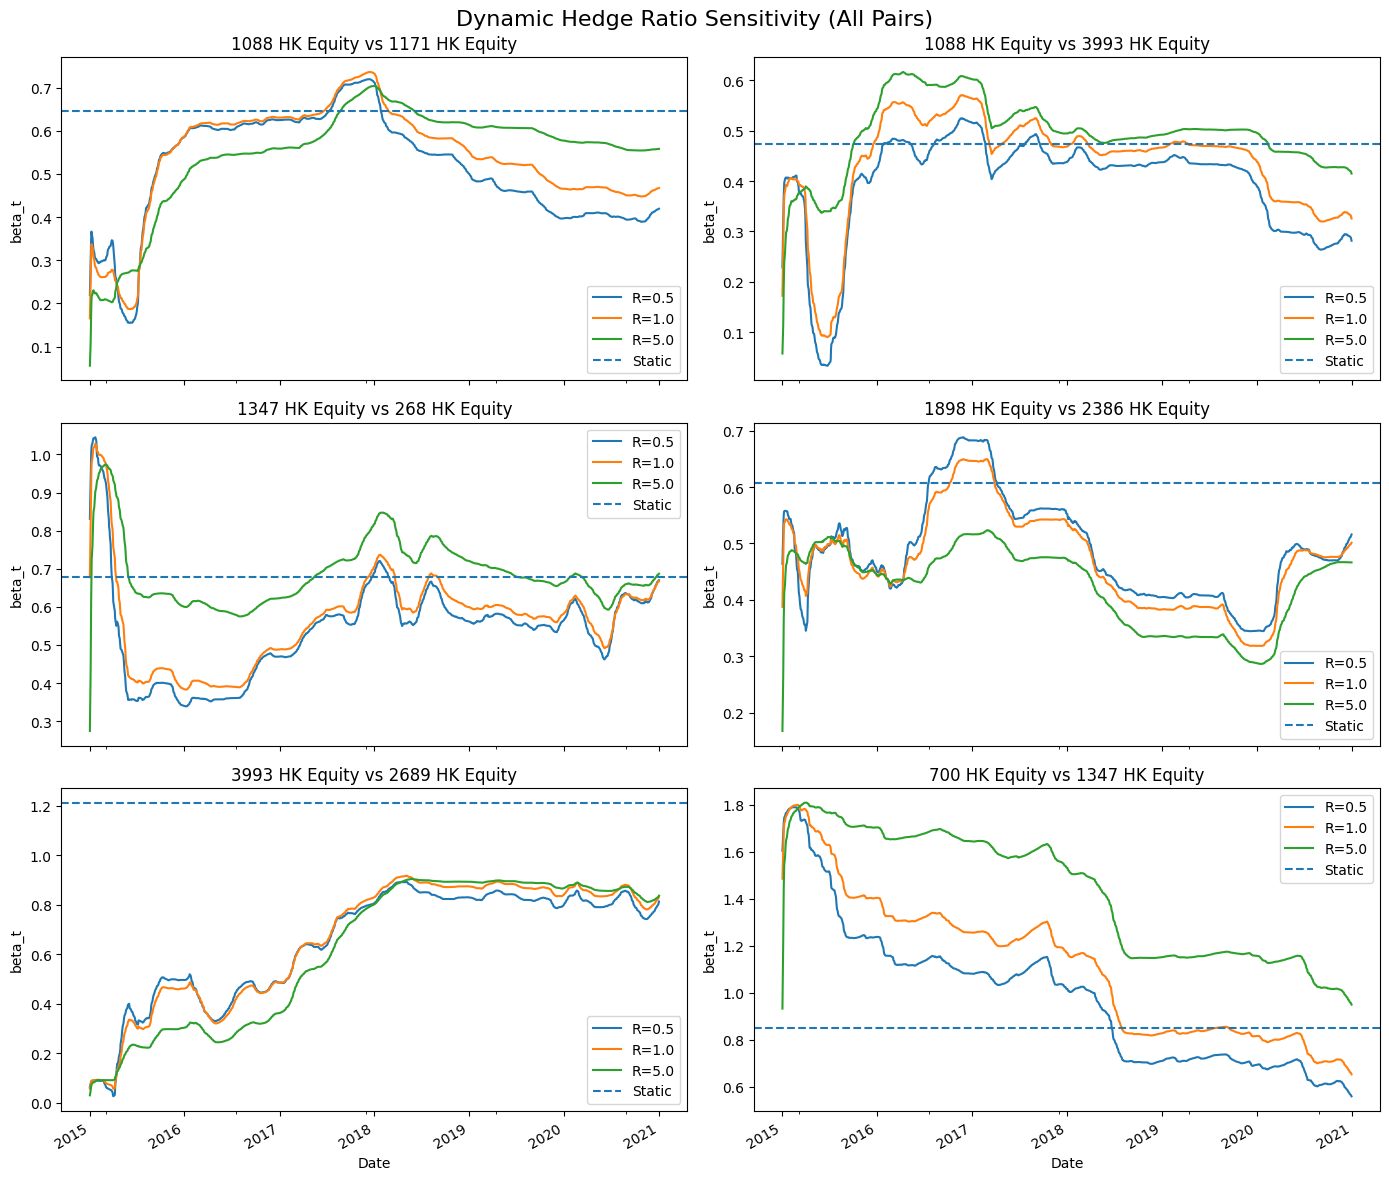

In [262]:
pair_names_is = sorted(
    set(pair_name for pair_name, r in dynamic_details_is.keys())
)

fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)

axes = axes.flatten()

for i, pair_name in enumerate(pair_names_is):
    ax = axes[i]

    for r in obs_cov_values:
        key = (pair_name, r)

        if key in dynamic_details_is:
            dynamic_details_is[key]["beta_t"].plot(
                ax=ax,
                label=f"R={r}"
            )

    # Static beta line
    static_beta = static_results_df.loc[
        static_results_df["pair"] == pair_name,
        "beta"
    ].iloc[0]

    ax.axhline(
        static_beta,
        linestyle="--",
        label="Static"
    )

    ax.set_title(pair_name)
    ax.set_ylabel("beta_t")
    ax.legend()

plt.suptitle(
    "Dynamic Hedge Ratio Sensitivity (All Pairs)",
    fontsize=16
)

plt.tight_layout()
plt.show()

The choice of the observation covariance parameter R reflects a trade-off between responsiveness and robustness. The theory suggests that lower values allow the filter to react more closely to observed price movements, but may lead to overfitting by capturing noise rather than genuine changes in the relationship. Conversely, higher values impose greater smoothness, potentially leading to underfitting. <br>

With the plots we see that while higher values of R produce smoother hedge ratios, they appear to lag structural changes in the relationship. Conversely, lower values introduce excessive variability. An intermediate value of R=1.0 provides a suitable balance, capturing time variation while avoiding excessive noise. Therefore, an intermediate value of R is preferred to balance adaptability and stability. We continue to use the observation covariance coefficient of 1.

In [263]:
dynamic_results_is = dynamic_results_df_is[dynamic_results_df_is["obs_cov (R)"] == 1.0]

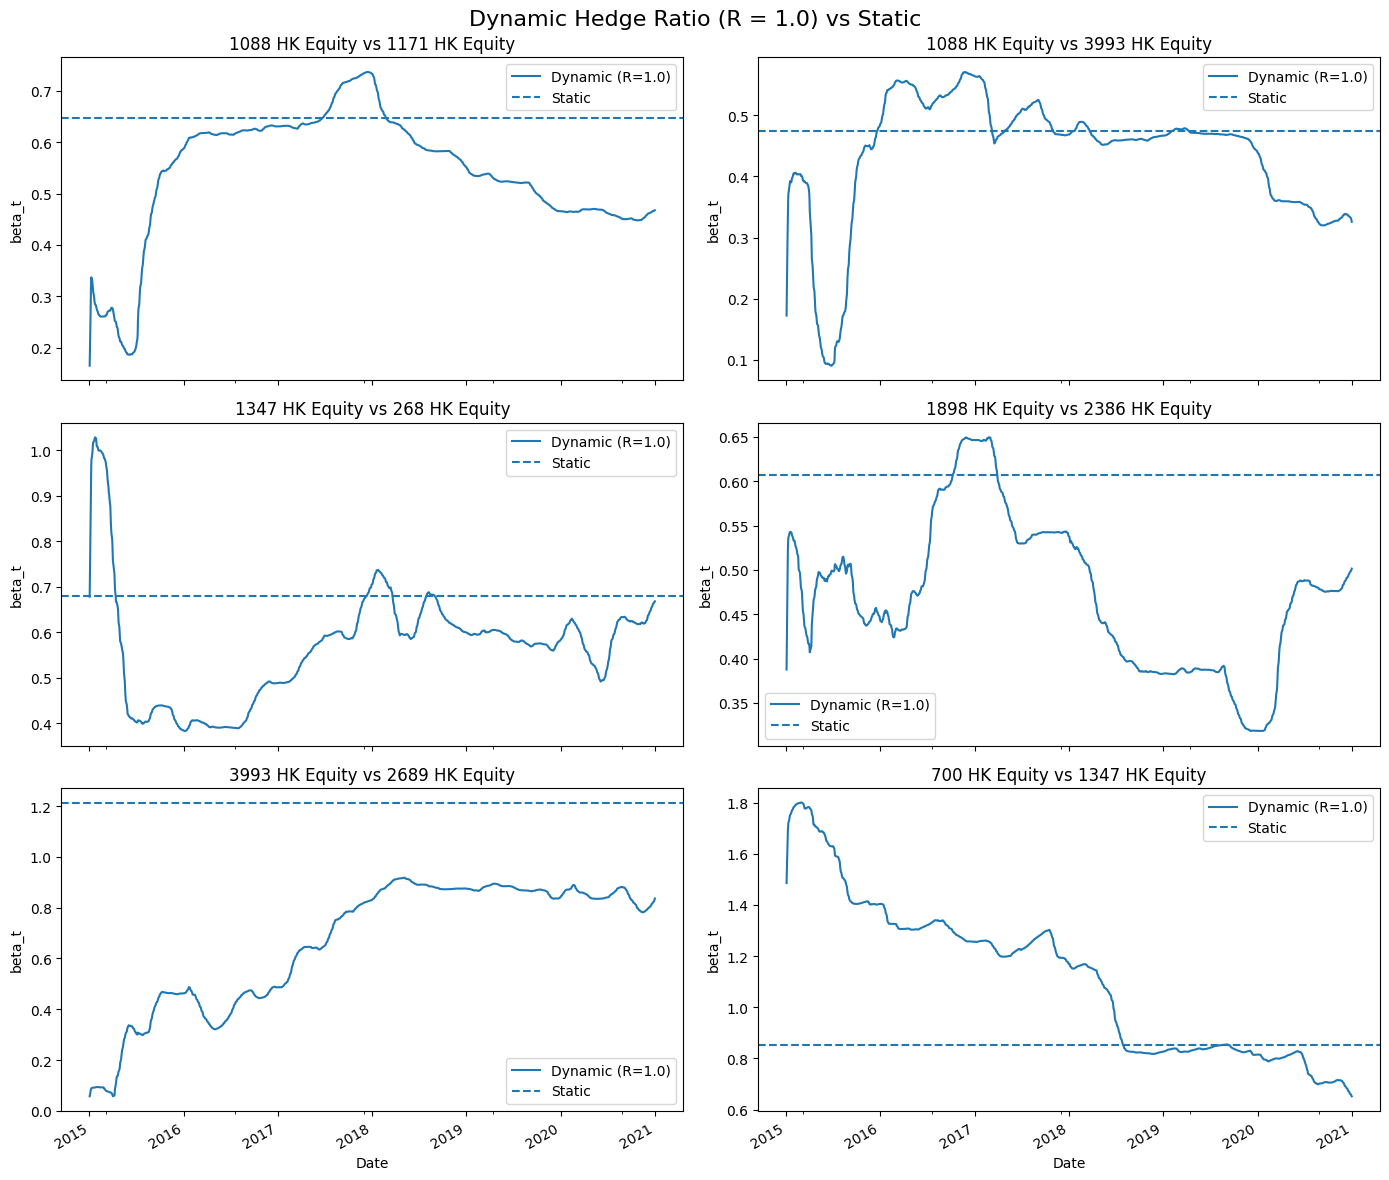

In [264]:
pair_names_is = sorted(set(pair_name for pair_name, r in dynamic_details_is.keys()))

fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)
axes = axes.flatten()

for i, pair_name in enumerate(pair_names_is):
    ax = axes[i]

    r = 1.0
    key = (pair_name, r)

    if key in dynamic_details_is:
        dynamic_details_is[key]["beta_t"].plot(ax=ax, label="Dynamic (R=1.0)")

    # static beta line
    static_beta = static_results_df.loc[
        static_results_df["pair"] == pair_name,
        "beta"   
    ].iloc[0]

    ax.axhline(static_beta, linestyle="--", label="Static")

    ax.set_title(pair_name)
    ax.set_ylabel("beta_t")
    ax.legend()

plt.suptitle("Dynamic Hedge Ratio (R = 1.0) vs Static", fontsize=16)
plt.tight_layout()
plt.show()

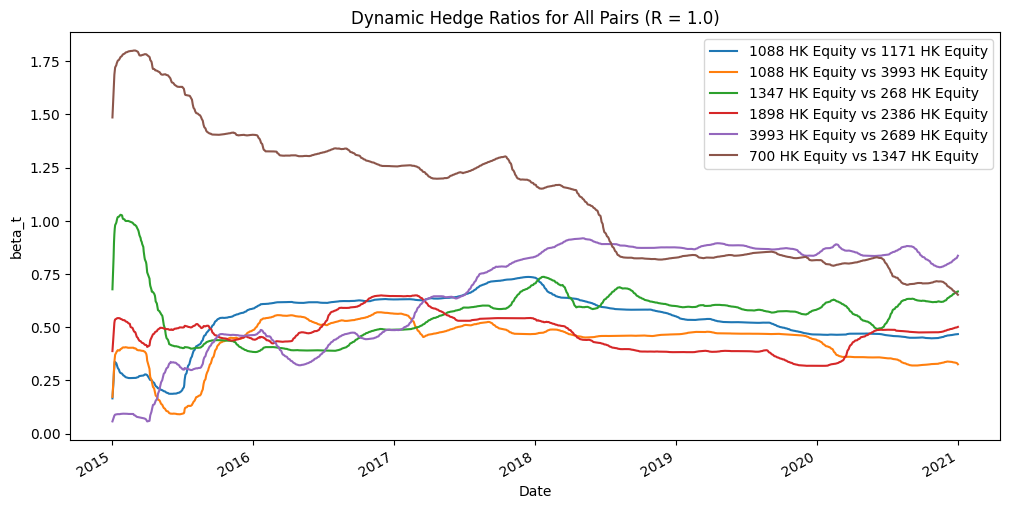

In [265]:
plt.figure(figsize=(12, 6))

pair_names_is = sorted(
    set(pair_name for pair_name, r in dynamic_details_is.keys())
)

for pair_name in pair_names_is:
    key = (pair_name, 1.0)

    if key in dynamic_details_is:
        dynamic_details_is[key]["beta_t"].plot(label=pair_name)

plt.title("Dynamic Hedge Ratios for All Pairs (R = 1.0)")
plt.xlabel("Date")
plt.ylabel("beta_t")
plt.legend()
plt.show()

In [266]:
# Save hedge ratio results
static_results_df_is.to_csv("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/static_hedge_ratio_is", index=False)
dynamic_results_df_is.to_csv("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/dynamic_hedge_ratio_is", index=False)

# Save spreads and details 
with open("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/dictionaries/static_spreads_is.pkl", "wb") as f:
    pickle.dump(static_spreads_is, f) 
with open("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/dictionaries/static_models_is.pkl", "wb") as f:
    pickle.dump(static_models_is, f) 

with open("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/dictionaries/dynamic_spreads_is.pkl", "wb") as f:
    pickle.dump(dynamic_spreads_is, f) 
with open("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/dictionaries/dynamic_details_is.pkl", "wb") as f:
    pickle.dump(dynamic_details_is, f) 

## *For OOS (in preparation for backtest comparison)*

In [267]:
pairs_oos = [
    {"y": "700 HK Equity", "x": "1347 HK Equity", "df": df1_oos},
    {"y": "1347 HK Equity", "x": "268 HK Equity", "df": df1_oos},
    {"y": "1088 HK Equity", "x": "3993 HK Equity", "df": df2_oos},
    {"y": "1088 HK Equity", "x": "1171 HK Equity", "df": df2_oos},
    {"y": "3993 HK Equity", "x": "2689 HK Equity", "df": df2_oos},
    {"y": "1898 HK Equity", "x": "2386 HK Equity", "df": df2_oos},
]

### Static Hedge Ratio

In [268]:
static_summaries_oos = []
static_spreads_oos = {}
static_models_oos = {}

for pair in pairs_oos:
    y_series = pair["df"][pair["y"]]
    x_series = pair["df"][pair["x"]]
    pair_name = f"{pair['y']} vs {pair['x']}"

    summary_df, spread, model = estimate_hedge_ratio_df(
        y_series,
        x_series,
        pair_name=pair_name
    )

    static_summaries_oos.append(summary_df)
    static_spreads_oos[pair_name] = spread
    static_models_oos[pair_name] = model

static_results_df_oos = pd.concat(static_summaries_oos, ignore_index=True)
static_results_df_oos

,pair,alpha,beta,r_squared,n_obs
0,700 HK Equity vs 1347 HK Equity,2.933033,0.858056,0.811788,511
1,1347 HK Equity vs 268 HK Equity,0.826788,0.900076,0.847502,511
2,1088 HK Equity vs 3993 HK Equity,4.048314,-1.063426,0.626154,511
3,1088 HK Equity vs 1171 HK Equity,1.808588,0.491713,0.960190,511
4,3993 HK Equity vs 2689 HK Equity,-0.079371,0.697759,0.827754,511
5,1898 HK Equity vs 2386 HK Equity,1.589398,-0.211053,0.004426,511


### Dynamic Hedge Ratio

In [269]:
dynamic_summaries_oos = []
dynamic_spreads_oos = {}
dynamic_details_oos = {}

obs_cov_values = [0.5, 1.0, 5.0]

for pair in pairs_oos:
    y_series = pair["df"][pair["y"]]
    x_series = pair["df"][pair["x"]]
    pair_name = f"{pair['y']} vs {pair['x']}"

    for r in obs_cov_values:
        summary_df, spread, data = estimate_dynamic_hedge_ratio_df(
            y_series,
            x_series,
            pair_name=pair_name,
            obs_cov=r
        )

        summary_df["obs_cov"] = r
        summary_df["pair"] = pair_name

        key = (pair_name, r)

        dynamic_summaries_oos.append(summary_df)
        dynamic_spreads_oos[key] = spread
        dynamic_details_oos[key] = data

dynamic_results_df_oos = pd.concat(dynamic_summaries_oos, ignore_index=True)

In [270]:
dynamic_results_df_oos.sort_values(
    by=["obs_cov", "pair"]
    ).reset_index(drop=True)

,pair,obs_cov (R),alpha_t_last,beta_t_last,beta_t_mean,beta_t_std,obs_cov
0,1088 HK Equity vs 1171 HK Equity,0.5,1.890660,0.467071,0.459410,0.122289,0.5
1,1088 HK Equity vs 3993 HK Equity,0.5,2.530062,0.282971,0.531447,0.182831,0.5
2,1347 HK Equity vs 268 HK Equity,0.5,1.093761,0.801817,0.888653,0.091749,0.5
3,1898 HK Equity vs 2386 HK Equity,0.5,0.666553,1.028132,1.135313,0.291615,0.5
4,3993 HK Equity vs 2689 HK Equity,0.5,-0.010572,0.647122,0.592220,0.029220,0.5
5,700 HK Equity vs 1347 HK Equity,0.5,2.125496,1.098754,1.304889,0.125042,0.5
6,1088 HK Equity vs 1171 HK Equity,1.0,1.835979,0.489847,0.500417,0.105861,1.0
7,1088 HK Equity vs 3993 HK Equity,1.0,2.485024,0.311099,0.606865,0.199015,1.0
8,1347 HK Equity vs 268 HK Equity,1.0,0.893122,0.870788,0.943529,0.063738,1.0
9,1898 HK Equity vs 2386 HK Equity,1.0,0.724698,0.960773,1.011266,0.264314,1.0


### Plotting hedge ratios

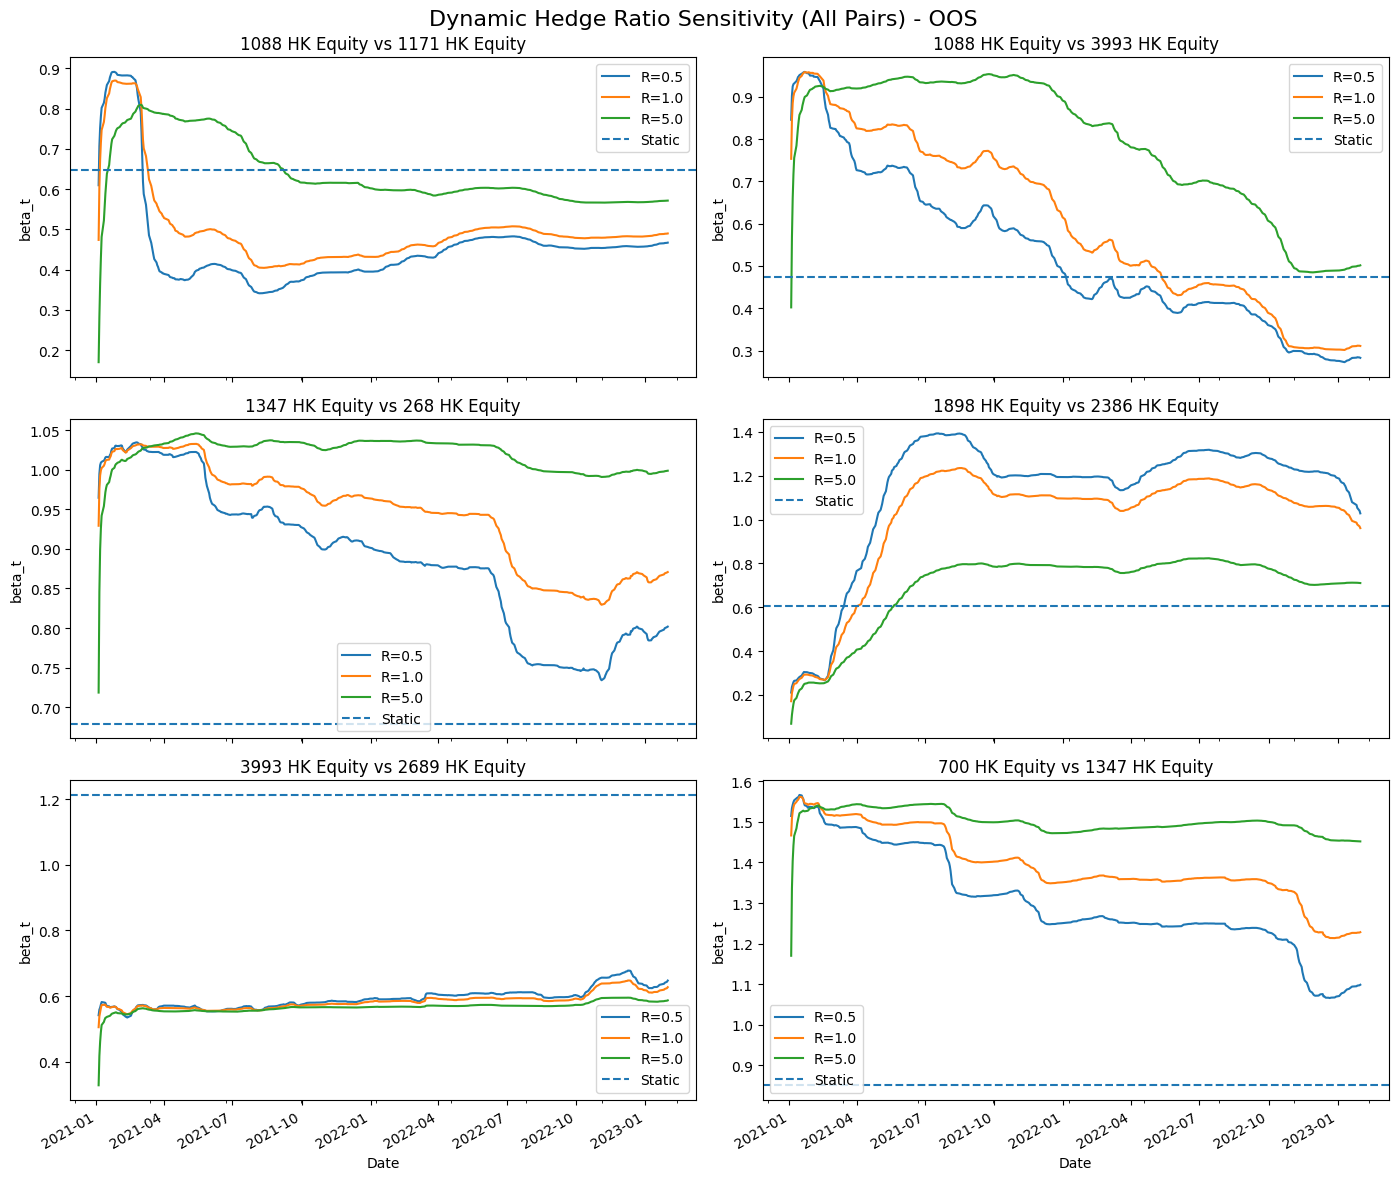

In [271]:
pair_names_oos = sorted(set(pair_name for pair_name, r in dynamic_details_oos.keys()))

fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)
axes = axes.flatten()

for i, pair_name in enumerate(pair_names_oos):
    ax = axes[i]

    for r in obs_cov_values:
        key = (pair_name, r)

        if key in dynamic_details_oos:
            dynamic_details_oos[key]["beta_t"].plot(ax=ax, label=f"R={r}")

    # static beta line
    static_beta = static_results_df.loc[
        static_results_df["pair"] == pair_name,
        "beta"
    ].iloc[0]

    ax.axhline(static_beta, linestyle="--", label="Static")

    ax.set_title(pair_name)
    ax.set_ylabel("beta_t")
    ax.legend()

plt.suptitle("Dynamic Hedge Ratio Sensitivity (All Pairs) - OOS", fontsize=16)
plt.tight_layout()
plt.show()

In [272]:
dynamic_results_oos = dynamic_results_df_oos[dynamic_results_df_oos["obs_cov (R)"] == 1.0]

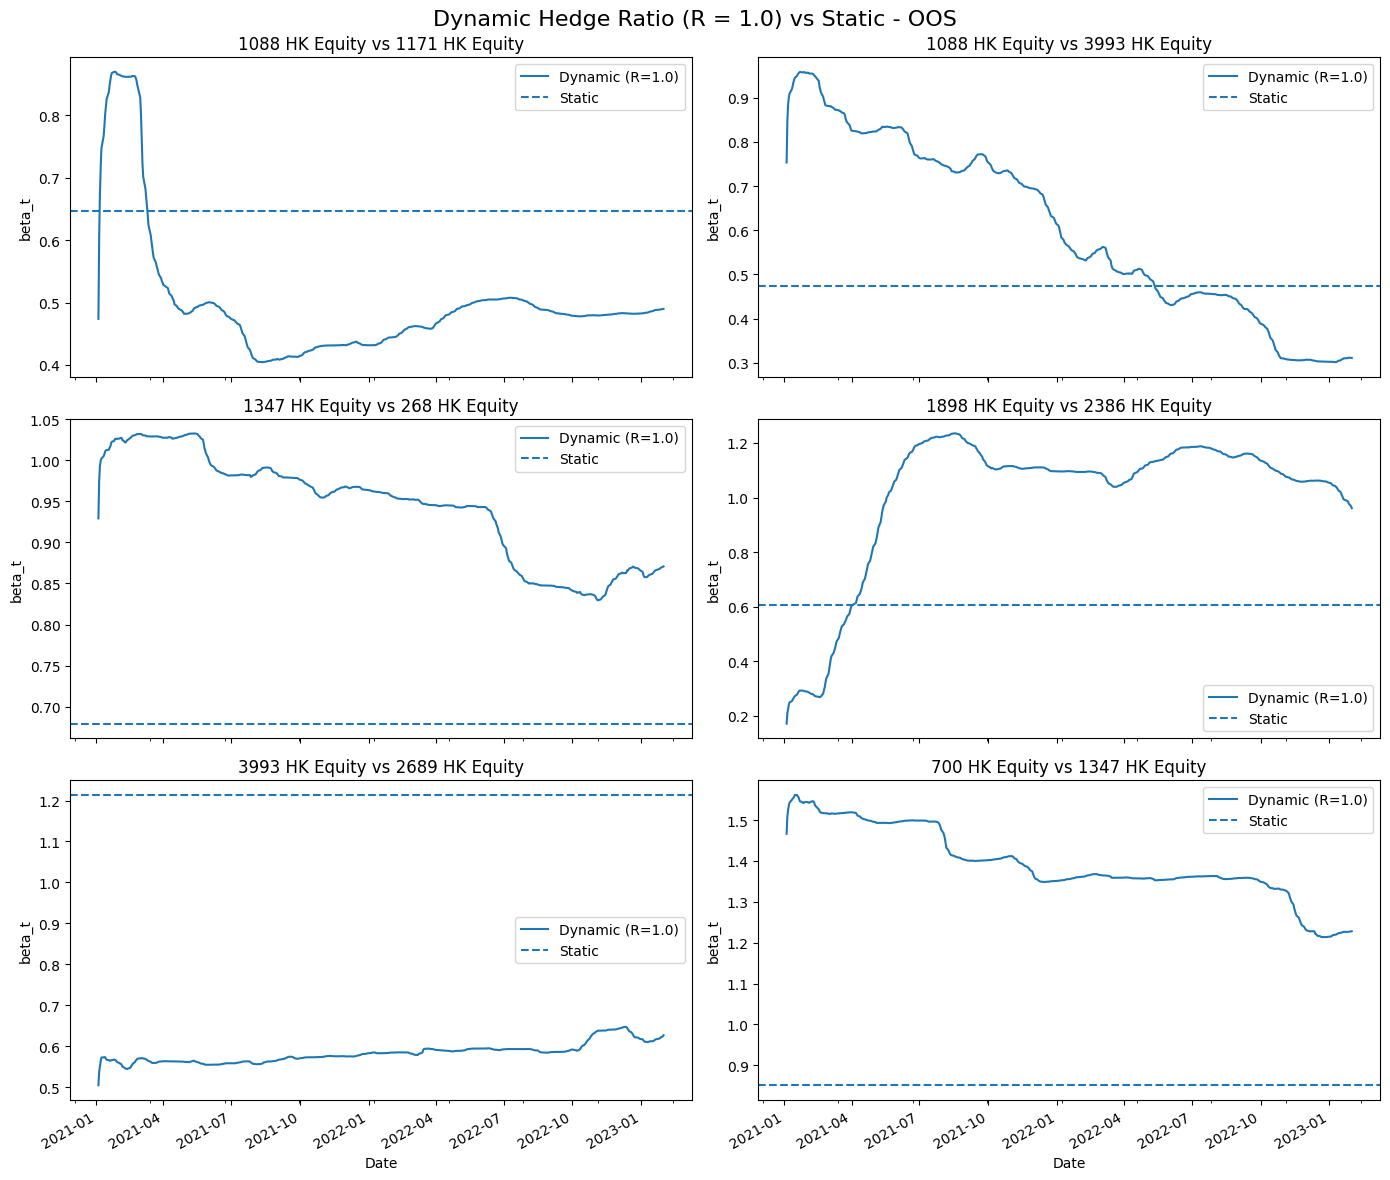

In [273]:
pair_names_oos = sorted(set(pair_name for pair_name, r in dynamic_details_is.keys()))

fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)
axes = axes.flatten()

for i, pair_name in enumerate(pair_names_oos):
    ax = axes[i]

    r = 1.0
    key = (pair_name, r)

    if key in dynamic_details_oos:
        dynamic_details_oos[key]["beta_t"].plot(ax=ax, label="Dynamic (R=1.0)")

    # static beta line
    static_beta = static_results_df.loc[
        static_results_df["pair"] == pair_name,
        "beta"   
    ].iloc[0]

    ax.axhline(static_beta, linestyle="--", label="Static")

    ax.set_title(pair_name)
    ax.set_ylabel("beta_t")
    ax.legend()

plt.suptitle("Dynamic Hedge Ratio (R = 1.0) vs Static - OOS", fontsize=16)
plt.tight_layout()
plt.show()

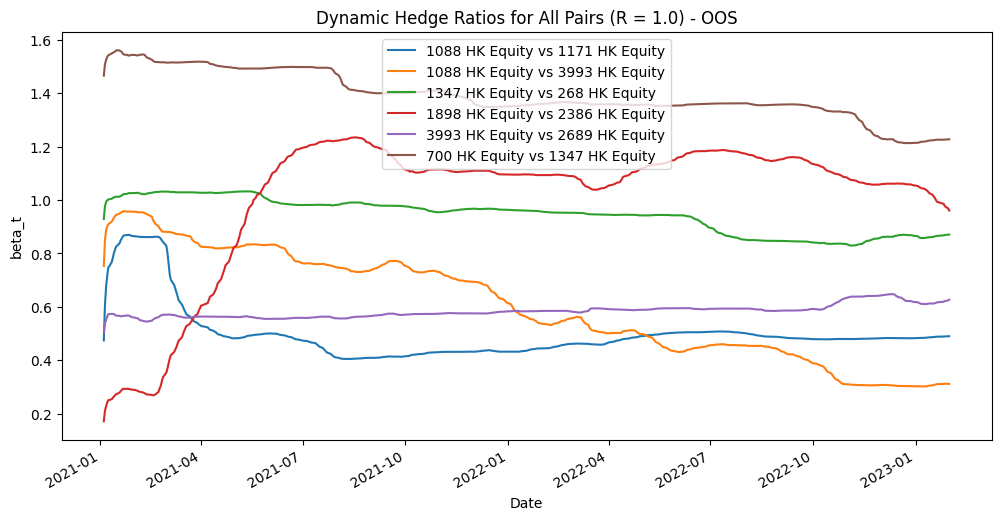

In [274]:
plt.figure(figsize=(12, 6))

pair_names_oos = sorted(
    set(pair_name for pair_name, r in dynamic_details_oos.keys())
)

for pair_name in pair_names_oos:
    key = (pair_name, 1.0)

    if key in dynamic_details_oos:
        dynamic_details_oos[key]["beta_t"].plot(label=pair_name)

plt.title("Dynamic Hedge Ratios for All Pairs (R = 1.0) - OOS")
plt.xlabel("Date")
plt.ylabel("beta_t")
plt.legend()
plt.show()

In [275]:
# Save pairs
with open("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/pairs_is.pkl", "wb") as f:
    pickle.dump(pairs_is, f)
with open("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/pairs_oos.pkl", "wb") as f:
    pickle.dump(pairs_oos, f)

# Save hedge ratio results
static_results_df_oos.to_csv("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/static_hedge_ratio_oos", index=False)
dynamic_results_df_oos.to_csv("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/dynamic_hedge_ratio_oos", index=False)

# Save spreads and details 
with open("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/dictionaries/static_spreads_oos.pkl", "wb") as f:
    pickle.dump(static_spreads_oos, f) 
with open("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/dictionaries/static_models_oos.pkl", "wb") as f:
    pickle.dump(static_models_oos, f) 

with open("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/dictionaries/dynamic_spreads_oos.pkl", "wb") as f:
    pickle.dump(dynamic_spreads_oos, f) 
with open("/Users/ivanhung/Documents/GitHub/applied-project-06039211/data/dictionaries/dynamic_details_oos.pkl", "wb") as f:
    pickle.dump(dynamic_details_oos, f) 